![](https://eap.bl.uk/themes/custom/eap/images/bl_logo_100.gif)
# Fetching Manifests and Images from the Endangered Archives Programme
https://eap.bl.uk/

[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1Oo7oJK65RXVhzY3newmvGtG69vnVOjS-)  


Most collections in the Engangered Archives Programme are publised online. This allows you to view the scanned materials on the British Library's site.

It is also possible to access these collections as data. The BL provides access to both metadata and images using the International Image Interoperability Framework (IIIF).

Let's work from an example of photgraphs from the Romani heritage in the Republic of Moldova collection(EAP699).


1. Go to https://eap.bl.uk/project/EAP699
2. Click on ["View archives from this project"](https://eap.bl.uk/project/EAP699/search)
3. Find the item, in this case ["Photographs"](https://eap.bl.uk/modules/custom/cogapp_collection_pages/images/logo_iiif.png)
4. Locate the IIIF icon (![](https://eap.bl.uk/modules/custom/cogapp_collection_pages/images/logo_iiif.png)) and get the link. You can click on the icon and select the address. You can also right-click on the icon and select "copy link".
5. You should get something that looks like the manifest URL below.

> A IIIF manifest is a package of data that contains descriptive metadata as well as links to all images in the relevant item.  



In [14]:
# @title Manifest URL
manifest_url = "https://eap.bl.uk/archive-file/EAP699-23-1/manifest?manifest=https%3A//eap.bl.uk/archive-file/EAP699-23-1/manifest"


In [15]:
# @title Fetch the manifest from EAP

import srsly
import requests

# The British Library blocks robots and other web crawlers from accessing their servers.  To signal that we are a human, we
# add a User-Agent to the request to show that we're a human. Do not share this with robots.
header = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/11"
}
manifest = requests.get(manifest_url, headers=header)
if manifest.status_code != 200:
  raise Exception(f"Error downloading manifest: {manifest.status_code}")

srsly.write_json('manifest.json', manifest.json())
# <-- In the files area to the left, you should now have a manifest.json file. Click on it to see the data.

manifest = manifest.json()


In [16]:
images = []
for canvas in manifest["sequences"][0]["canvases"]:
  for image in canvas["images"]:
    image_uri = image.get('resource', None).get('@id', None)
    if image_uri:
      images.append(image_uri)
print(f"Found {len(images)} images in manifest")

Found 4 images in manifest

What is contained in our images list? Let's look at one of them using the index position in the list.

Once displayed, copy the output and try loading it in the browser.

In [17]:
images[:4]

['https://images.eap.bl.uk/EAP699/EAP699_23_1/1.jp2/full/full/0/default.jpg',
 'https://images.eap.bl.uk/EAP699/EAP699_23_1/2.jp2/full/full/0/default.jpg',
 'https://images.eap.bl.uk/EAP699/EAP699_23_1/3.jp2/full/full/0/default.jpg',
 'https://images.eap.bl.uk/EAP699/EAP699_23_1/4.jp2/full/full/0/default.jpg']

In [7]:
from IPython.display import Image
Image(url=images[3], width=400)

Beyond serving images and metadata to the Web, the IIIF also allows for many transformations of the image just by changing the URL. You can request a black and white version, a cropped version, or a resized version. See the [IIIF Image API documentation](https://iiif.io/api/image/3.0/) for more details.

While the model that were using is able to process images of any size, larger images will use more memory. To reduce memory usage, we can request smaller versions of the images by changing the IIIF URL. Here, we will request images that are 400 pixels wide.

In [22]:
def resize_image(image_url, new_width=400, new_height=''):
  #{scheme}://{server}{/prefix}/{identifier}/{region}/{size}/{rotation}/{quality}.{format}
  # https://iiif.io/api/image/3.0/#21-image-request-uri-syntax
  size = image_url.split('/')[-3]
  region = image_url.split('/')[-4]
  image_url = image_url.replace(f'/{region}/{size}/', f'/{region}/{new_width},{new_height}/')
  return image_url

images = [resize_image(image) for image in images]
images

['https://images.eap.bl.uk/EAP699/EAP699_23_1/1.jp2/full/400,/0/default.jpg',
 'https://images.eap.bl.uk/EAP699/EAP699_23_1/2.jp2/full/400,/0/default.jpg',
 'https://images.eap.bl.uk/EAP699/EAP699_23_1/3.jp2/full/400,/0/default.jpg',
 'https://images.eap.bl.uk/EAP699/EAP699_23_1/4.jp2/full/400,/0/default.jpg']

## Prompt 

The prompt contains your instructions to the model. You can modify this to change the behavior of the model.For now, we'll keep it simple and generate alt-text descriptions for each image.

In [41]:
from rich import print
prompt = """Describe the image for use as alt-text."""
print(prompt)

Describe the image for use as alt-text.

# Models 

### Endpoint approach 
There are many models and many ways to run them. For this workshop, we'll provide you with an endpoint to access a model using a REST API. This allows you to use the model without needing a GPU. At the end, we'll give you instruction on how to create your own endpoint if this approach is best for you. Our code works with most other model endpoint providers such as OpenAI, Anthropic and others. We're model agnostic, so you can choose the model that works best for you as things change rapidly in this space.



In [42]:
base_url = "https://glw30r2npdvyvzho.us-east-1.aws.endpoints.huggingface.cloud/v1/"
api_key = "$HF_TOKEN"

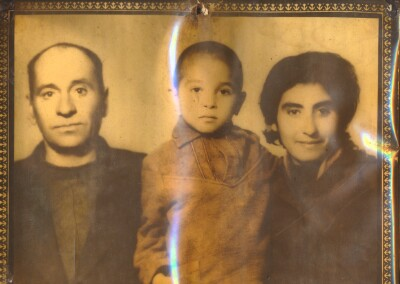

A vintage, sepia-toned family portrait of three people: a man on the left, a young child in the center, and a woman
on the right. The photo is framed with an ornate, decorative border and shows signs of age, including a noticeable 
rainbow-like light reflection on the right side. All three subjects are looking directly at the camera with serious
expressions.

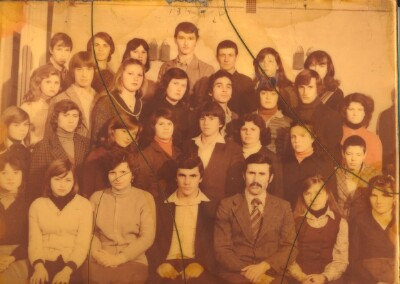

This is a vintage, sepia-toned class photograph of a group of young people, likely students, arranged in rows. The 
image shows signs of age, including creases and discoloration. In the front row, a man in a suit and tie sits 
centrally, flanked by several young women and men. Behind him, more students are seated and standing, all looking 
toward the camera. The overall atmosphere suggests a formal school or group portrait from the mid-20th century.

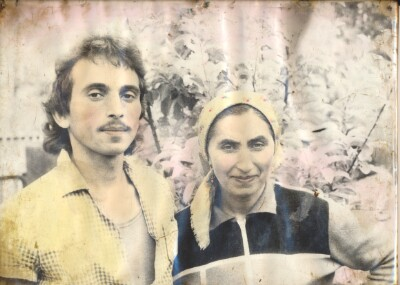

A faded, vintage photograph of a man and a woman standing side by side outdoors. The man on the left has wavy dark 
hair, a mustache, and wears a light-colored, patterned shirt. The woman on the right wears a headscarf and a dark 
vest over a lighter top, smiling gently. The background is softly blurred with hints of foliage and pink blossoms, 
suggesting a garden or park setting. The image shows signs of age, with discoloration and wear along the edges.

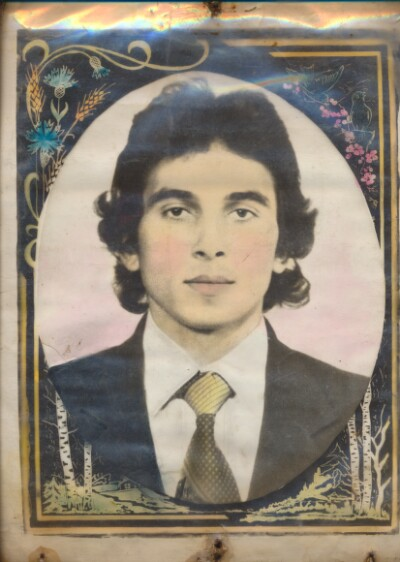

This is a vintage, hand-tinted portrait of a young man, likely from the mid-20th century. He has dark, wavy, 
shoulder-length hair and is looking directly at the viewer with a neutral expression. He is dressed formally in a 
dark suit jacket, a white collared shirt, and a patterned yellow and brown tie. The portrait is oval-shaped and set
within an ornate, decorative border featuring floral and botanical motifs, including blue flowers, wheat stalks, 
and birch trees, all rendered in a stylized, hand-colored style. The entire image appears aged, with visible 
yellowing, creases, and some discoloration along the edges, suggesting it is an old photograph or print.

In [43]:
# pip install openai 

from openai import OpenAI 
from PIL import Image

def process_image_urls(prompt:str, image_urls: list[str], base_url: str, api_key: str) -> list[str]:
	
	client = OpenAI(
		base_url = base_url,
		api_key = api_key
	)
	output = []
	for image in image_urls:
		chat_completion = client.chat.completions.create(
			model = "Qwen/Qwen3-VL-8B-Instruct",
			messages = [
				{
					"role": "user",
					"content": [
						{
							"type": "image_url",
							"image_url": {
								"url": image
							}
						},
						{
							"type": "text",
							"text": prompt
						}
					]
				}
			],
			stream = True,
			temperature = 0,
			#max_tokens = 100
		)

		response_text = ""
		for chunk in chat_completion:
			token = getattr(chunk.choices[0].delta, "content", None)
			if token:
				response_text += token
		output.append(response_text)
	return output

predictions = process_image_urls(prompt, images, base_url, api_key)
for image, prediction in zip(images, predictions):
	if image and prediction:
		img = Image.open(requests.get(image, headers=header, stream=True).raw)
		display(img)
		print(prediction)


# Processing with Metadata
On its own the model gives relatively generic and unhelpful descriptions. However, we can use the metadata from the EAP when generating the description.

In [44]:
from rich import print
# @title Initial Prompt
prompt = """Describe the contents of the image."""
print(prompt)

Describe the contents of the image.

In [45]:
# @title Prompt + Metadata

prompt += """\nUse the following metadata as context: \n"""
manifest = srsly.read_json('manifest.json')
for metadata in manifest['metadata']:
  prompt += f"{metadata['label']}: {metadata['value']}\n"
print(prompt)

Describe the contents of the image.
Use the following metadata as context: 
Identifier: EAP699/23/1
Title: Photographs
Place: Moldova, Europe
Link to catalogue record: <a href="https://eap.bl.uk/archive-file/EAP699-23-1">View the catalogue record</a>
Citation: Photographs, British Library, EAP699/23/1, https://eap.bl.uk/archive-file/EAP699-23-1
Digitised by: Institute of the Cultural Heritage of the Academy of Sciences of Moldova
Digitisation funded by: Endangered Archives Programme supported by Arcadia
Language: Romanian, Russian
Scripts: Cyrillic, Latin

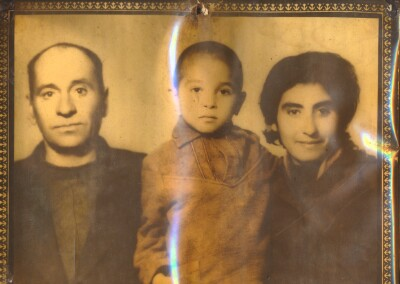

This is a sepia-toned, vintage family portrait, likely from the early to mid-20th century, featuring three 
individuals posed formally against a plain, light-colored backdrop.

From left to right:

*   **A man**: He appears to be an adult, with a balding head and a serious, direct gaze. He is wearing a dark, 
high-collared jacket or shirt.
*   **A young boy**: Positioned in the center, he is looking forward with a solemn expression. He is dressed in a 
light brown or tan jacket or coat.
*   **A woman**: On the right, she has dark, wavy hair and is also looking directly at the camera with a composed 
expression. She is wearing a dark, possibly patterned, garment.

The photograph is framed in a simple, ornate, dark-colored frame with a decorative border. A noticeable vertical 
rainbow-like reflection or glare is visible on the right side of the image, likely caused by the lighting during 
the digitization process. The overall image has a faded, aged quality, consistent with its historical origin.

The metadata indicates this photograph is part of the British Library's Endangered Archives Programme collection 
(EAP699/23/1), originating from Moldova, Europe, and was digitized by the Institute of the Cultural Heritage of the
Academy of Sciences of Moldova. The languages and scripts associated with the region are Romanian and Russian, 
using Latin and Cyrillic scripts.

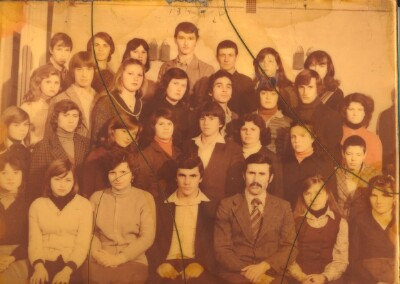

This is a vintage, sepia-toned group photograph, likely from the late 20th century, depicting a class or group of 
young people, possibly students, in Moldova, Europe.

The image shows approximately 25-30 individuals arranged in several rows. The front row is seated, while the rows 
behind are standing. The subjects are dressed in formal or semi-formal attire typical of the era, including 
sweaters, collared shirts, and jackets. A man in the front row, positioned centrally, wears a suit and tie, 
suggesting he may be a teacher or a figure of authority.

The photograph exhibits signs of age, including visible creases, scratches, and discoloration, particularly along 
the edges and across the surface. The overall tone is warm and faded, characteristic of older photographic prints.

The metadata indicates this photograph is part of the British Library’s Endangered Archives Programme collection 
(EAP699/23/1), digitised by the Institute of the Cultural Heritage of the Academy of Sciences of Moldova. The 
collection includes materials in Romanian and Russian, using both Cyrillic and Latin scripts, reflecting the 
linguistic context of Moldova.

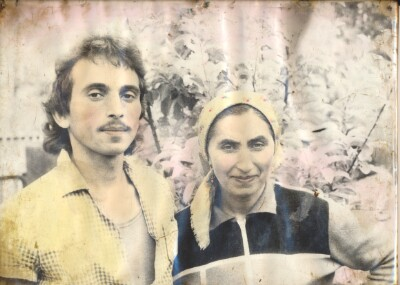

This is a vintage, slightly faded color photograph, likely from the late 20th century, depicting a man and a woman 
posing together outdoors.

- **The Man (left):** He has dark, wavy, shoulder-length hair and a mustache. He is wearing a light-colored, 
possibly yellow or beige, collared shirt with a subtle pattern. He is looking directly at the camera with a neutral
expression.

- **The Woman (right):** She has dark hair covered by a light-colored headscarf or head covering. She is wearing a 
dark vest or jacket over a lighter-colored top. She is smiling gently at the camera.

- **Background:** The background is softly blurred and appears to be an outdoor setting with trees or bushes, 
possibly in bloom, given the light pinkish hues. The overall image has a warm, aged tone and shows signs of wear, 
such as creases and discoloration, consistent with an old photograph.

The photograph is part of the British Library’s Endangered Archives Programme collection (EAP699/23/1), digitized 
by the Institute of the Cultural Heritage of the Academy of Sciences of Moldova. It originates from Moldova, 
Europe, and is associated with Romanian and Russian languages and scripts.

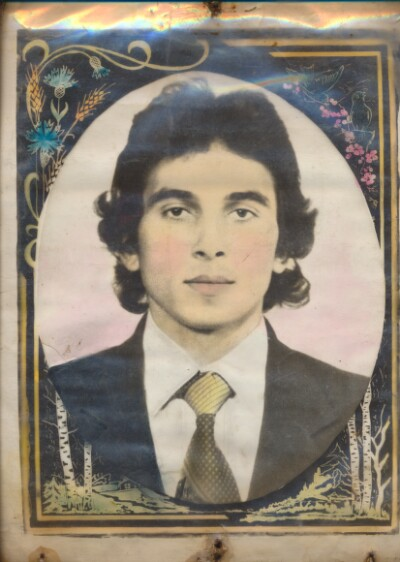

This is a vintage, oval portrait photograph of a young man, likely from the mid-20th century, set within an ornate,
decorative border.

**Subject:**
The central figure is a young man with dark, wavy, shoulder-length hair. He is looking directly at the camera with 
a neutral expression. He is dressed formally in a dark suit jacket, a white collared shirt, and a patterned tie 
with diagonal stripes in shades of yellow and brown.

**Frame and Background:**
The photograph is framed within an elaborate, hand-painted or printed decorative border. The border features:
*   A dark blue background with gold trim.
*   Ornamental flourishes, including stylized flowers (blue and pink blossoms) and wheat stalks in the upper 
corners.
*   A landscape scene at the bottom, depicting birch trees and what appears to be a small house or cottage.
*   The entire image is mounted on a slightly yellowed, aged paper or card, which shows some wear and tear, 
including small holes and discoloration at the bottom edge.

**Metadata Context:**
This photograph is part of the "Photographs" collection (Identifier: EAP699/23/1) from Moldova, Europe. It was 
digitized by the Institute of the Cultural Heritage of the Academy of Sciences of Moldova as part of the Endangered
Archives Programme. The collection includes materials in Romanian and Russian, using both Cyrillic and Latin 
scripts.

The image captures a formal portrait, likely taken for personal or official records, reflecting the photographic 
style and cultural context of Moldova during the period.

In [46]:
predictions = process_image_urls(prompt, images, base_url, api_key)
for image, prediction in zip(images, predictions):
	if image and prediction:
		img = Image.open(requests.get(image, headers=header, stream=True).raw)
		display(img)
		print(prediction)